# Teletransporte cuántico

El teletransporte cuántico mueve el estado de un qubit a otro, usando entrelazamiento y comunicación clásica, sin mover materia ni transmitir nada más rápido que la luz: solo se transmite el estado, y hace falta el canal clásico para completar el proceso. Este notebook construye una versión mínima con tres qubits.

## El protocolo, en palabras

Alice tiene un qubit con el estado que quiere enviar a Bob. Alice y Bob comparten de antemano un par de Bell, uno de sus qubits cada uno. Alice combina su qubit con su mitad del par de Bell, mide los dos, y envía esos bits clásicos a Bob. Con esa información, Bob aplica una corrección a su propio qubit, X, Z, ninguna o ambas, según los bits recibidos, y su qubit termina con el estado original.

## Por qué esta versión es distinta

El protocolo de libro de texto mide dos qubits a mitad de circuito y aplica una corrección condicionada al resultado. Polypus no soporta eso: solo admite medir al final, con `measure` o `measure_all`, sin condicionales clásicos sobre el resultado de una medida.

La solución es aplicar las correcciones como puertas cuánticas controladas, antes de medir, en vez de como puertas clásicas condicionadas después de medir. Por el principio de medida diferida, ambas versiones dan el mismo resultado físico: una CX o CZ controlada por un qubit se comporta igual que una X o Z aplicada tras medir ese qubit y actuar según el resultado.

## Construir el circuito

El qubit 0 guarda el estado a enviar, el 1 es la mitad de Alice del par de Bell, y el 2 es la mitad de Bob, donde debería terminar el estado:

In [5]:
import math

import polypus

theta = math.pi / 3

qc = polypus.Circuit(3)
qc.rx(0, theta)  # estado a teletransportar, en el qubit 0
qc.h(1)  # par de Bell entre los qubits 1 y 2
qc.cx(1, 2)
qc.cx(0, 1)  # Alice combina su qubit con su mitad del par de Bell
qc.h(0)
qc.cx(1, 2)  # corrección X diferida
qc.cz(0, 2)  # corrección Z diferida
qc.measure_all()

Circuit(num_qubits=3, num_params=0, gates=8)

Con el patrón visto en `02b`, se puede ver el circuito completo:

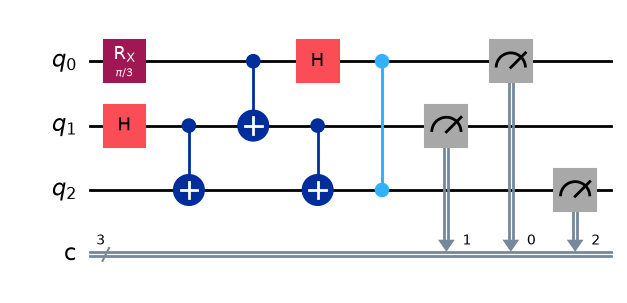

In [6]:
from qiskit import qasm2

qc_dibujo = qasm2.loads(
    qc.to_qasm2(), custom_instructions=qasm2.LEGACY_CUSTOM_INSTRUCTIONS
)
qc_dibujo.draw("mpl")

## Comprobar el resultado

Con `rx(0, theta)`, la probabilidad teórica de medir el qubit 0 en `1` es `sin²(theta/2)`. Si el teletransporte funciona, el qubit 2 debería reproducir esa misma probabilidad:

In [7]:
result = polypus.run_quantum_circuit(qc, shots=10000, infrastructure="local")
counts = result.counts[0]

total = sum(counts.values())
p1_qubit2 = sum(c for bits, c in counts.items() if bits[0] == "1") / total

print("medido:", p1_qubit2)
print("teórico:", math.sin(theta / 2) ** 2)

medido: 0.2528
teórico: 0.24999999999999994


El primer carácter del string medido corresponde al último qubit del circuito, el 2 en este caso: Polypus ordena los bits medidos de mayor a menor índice de qubit, de izquierda a derecha. Los dos valores coinciden dentro del margen esperado por el ruido de muestreo: el estado se ha movido de verdad del qubit 0 al 2.

## Resumen

Este notebook ha construido el teletransporte cuántico con tres qubits, sustituyendo la medida a mitad de circuito y la corrección clásica del protocolo de libro de texto por el equivalente de puertas controladas antes de medir, y ha comprobado que el estado llega intacto al qubit de destino comparando su probabilidad con el valor teórico.

La siguiente sección cubre otra construcción clásica: la transformada de Fourier cuántica.

## Siguiente paso

Continúa con: [`04b_qft.ipynb`](04b_qft.ipynb).